In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from src.models.catboost_classifier import train_catboost
from src.models.metrics import evaluate_model, feature_importance
from src.models.threshold import find_best_threshold
from src.visualization.plots import (
    plot_roc_curve,
    plot_feature_importance,
    plot_threshold_metrics,
    plot_confusion_matrix,
)

TRAIN CATBOOST MODEL

0:	total: 479ms	remaining: 7m 58s
100:	total: 32.5s	remaining: 4m 49s
200:	total: 1m	remaining: 4m
300:	total: 1m 29s	remaining: 3m 28s
400:	total: 2m 5s	remaining: 3m 7s
500:	total: 2m 41s	remaining: 2m 40s
600:	total: 3m 16s	remaining: 2m 10s
700:	total: 3m 52s	remaining: 1m 39s
800:	total: 4m 28s	remaining: 1m 6s
900:	total: 5m 29s	remaining: 36.2s
999:	total: 6m 29s	remaining: 0us

Best threshold
threshold    0.750000
precision    0.072426
recall       0.172667
f1           0.102048
Name: 74, dtype: float64
CatBoost best threshold: 0.750

 CatBoost Classification Report
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    415082
           1       0.07      0.17      0.10      6666

    accuracy                           0.95    421748
   macro avg       0.53      0.57      0.54    421748
weighted avg       0.97      0.95      0.96    421748


 CatBoost Metrics
ROC-AUC: 0.7556
PR_AUC: 0.0497
Accuracy: 0.9520
Precision: 0.0724
Recall:

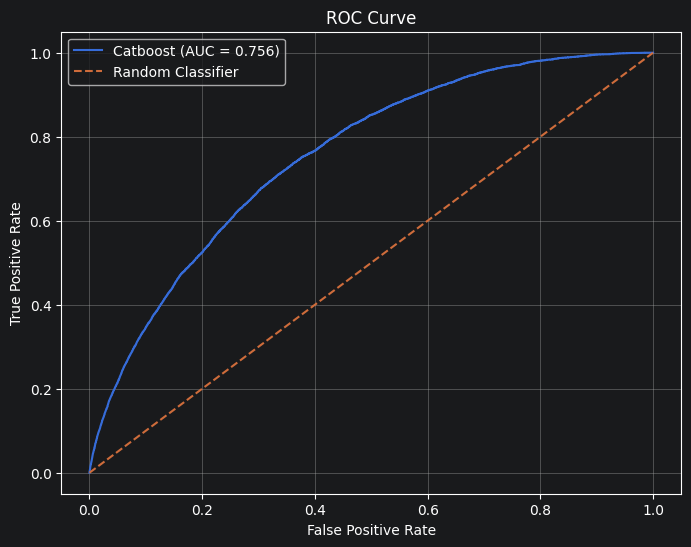

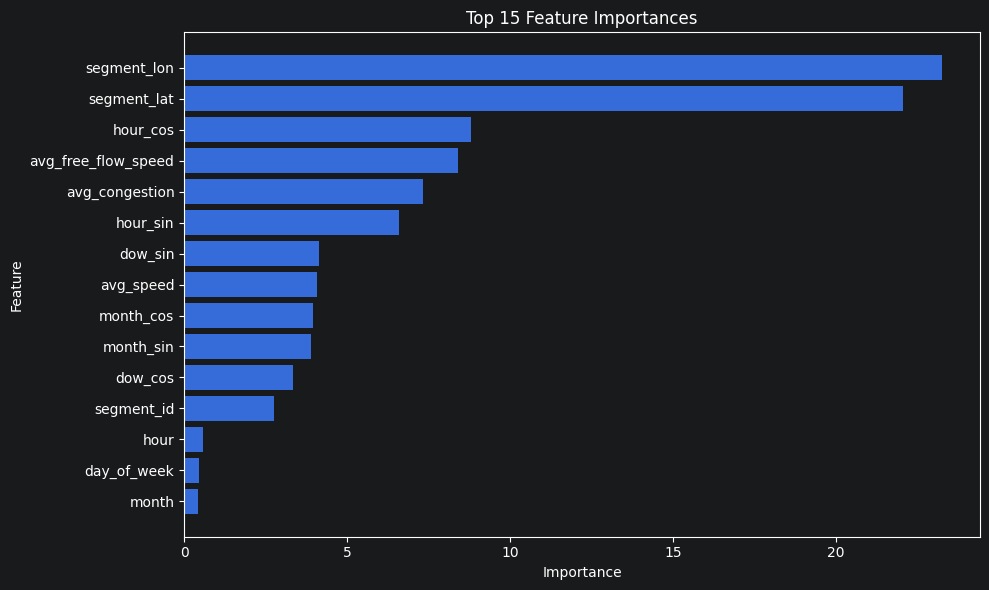

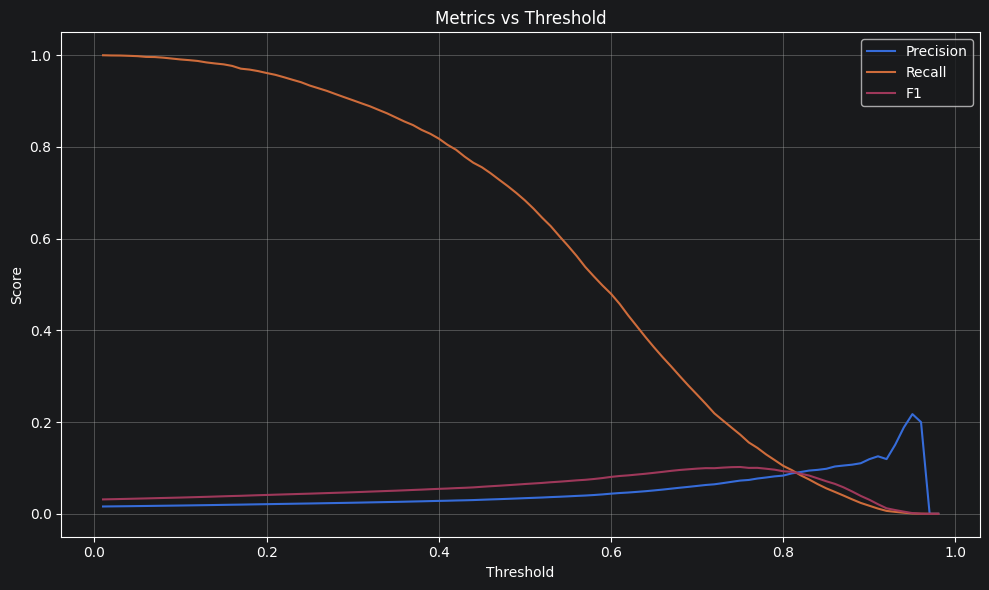

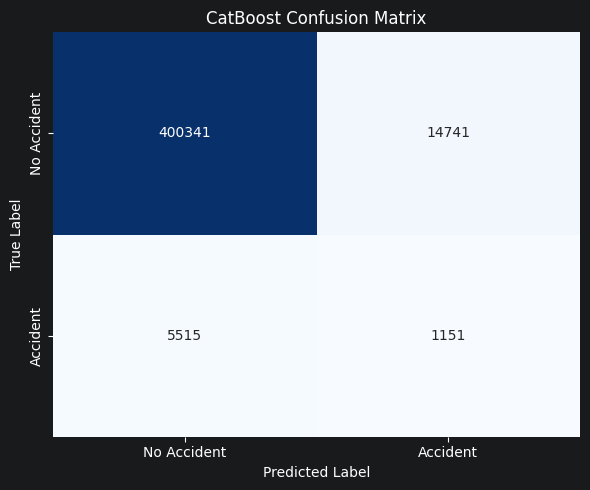

In [2]:
df = pd.read_parquet("../data/processed/traffic_crashes_hourly.parquet")

FEATURES_NUMERIC = [
    "avg_speed",
    "avg_free_flow_speed",
    "avg_congestion",
    "segment_lat",
    "segment_lon",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

FEATURES_CATEGORICAL = [
    "segment_id",
    "hour",
    "day_of_week",
    "month",
]

FEATURES = FEATURES_NUMERIC + FEATURES_CATEGORICAL

TARGET = "accident"

X = df[FEATURES]

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

catboost = train_catboost(X_train, y_train, X_test, y_test, FEATURES_CATEGORICAL)

(
    model,
    y_proba,
    _,
    importance_pred_val,
    importance_loss,
    shap_values
) = catboost

best_threshold_catboost, threshold_results_catboost = (
    find_best_threshold(
        y_test,
        y_proba
    )
)

print(
    f"CatBoost best threshold: {best_threshold_catboost:.3f}"
)

y_pred = (
    y_proba >= best_threshold_catboost
).astype(int)

metrics_catboost = evaluate_model(
    y_test,
    y_pred,
    y_proba,
    "CatBoost"
)

feature_importance(importance_pred_val, FEATURES, False)

plot_roc_curve(y_test, y_proba, 'Catboost', metrics_catboost["ROC-AUC"])

plot_feature_importance(importance_pred_val, FEATURES)

plot_threshold_metrics(
    threshold_results_catboost
)

plot_confusion_matrix(
    y_test,
    y_pred,
    "CatBoost"
)